# Steps 
1. Import all the Libraries 
2. Import the Datasets 
3. Perform Data Analysis & EDA (Data Cleaning , manipulation , exploration , visualisation)
4. Spliting of data 
5. [Optional] Data Preprocessing - Feature Scaling .. 
6. Choosing a model - Decision Tree Regressor 
7. Training the model 
8. Testing the model 
9. Checking the Performance of the model 

# Importing the Libraries 

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import re 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score , mean_absolute_percentage_error,mean_squared_error

# Problem Statement

* we have to predict the selling price 

# Importing the Dataset

In [4]:
df = pd.read_csv('car_data.csv')

In [5]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [6]:
df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner
4339,Renault KWID RXT,2016,225000,40000,Petrol,Individual,Manual,First Owner


In [7]:
df.shape #tells no. of rows and columns 

(4340, 8)

In [8]:
df.ndim # Dimention

2

In [9]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [11]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [12]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [13]:
# how many unique valuesin fuel and what are those
df.fuel.unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [14]:
df.seller_type.unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [15]:
df.transmission.unique()

array(['Manual', 'Automatic'], dtype=object)

In [16]:
df.owner.unique()

array(['First Owner', 'Second Owner', 'Fourth & Above Owner',
       'Third Owner', 'Test Drive Car'], dtype=object)

# create a column - new_fuel and place it at the position of fuel 
# replace the values :
* petrol - 0
* Diesel - 1
* CNG - 2
* LPG - 3
* Electric - 4  

In [17]:
df.fuel

0       Petrol
1       Petrol
2       Diesel
3       Petrol
4       Diesel
         ...  
4335    Diesel
4336    Diesel
4337    Petrol
4338    Diesel
4339    Petrol
Name: fuel, Length: 4340, dtype: object

In [18]:
dff = df.copy()

In [19]:
dff.fuel.unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [20]:
f = {'Petrol': 0, 'Diesel':1, 'CNG':2, 'LPG':3, 'Electric':4}

In [21]:
dff['new_fuel'] = df.fuel.map(f)

In [22]:
dff

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,new_fuel
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,1
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,1
...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner,1
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner,1
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner,0
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner,1


In [23]:
df.insert(4,'new_fuel',dff.new_fuel.values)

In [24]:
df

,name,year,selling_price,km_driven,new_fuel,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,1,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,1,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,0,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,1,Diesel,Individual,Manual,First Owner


In [25]:
df.new_fuel.unique()

array([0, 1, 2, 3, 4], dtype=int64)

In [26]:
df.seller_type.unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [27]:
y = {'Individual':1, 'Dealer':2, 'Trustmark Dealer':3}
dff['new_seller_type'] = df.seller_type.map(y)

In [28]:
df.insert(6,'new_seller_type',dff.new_seller_type.values)

In [29]:
df.drop(columns='new_seller_type',inplace=True)

In [30]:
df

,name,year,selling_price,km_driven,new_fuel,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,1,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,1,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,0,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,1,Diesel,Individual,Manual,First Owner


In [31]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'new_fuel', 'fuel',
       'seller_type', 'transmission', 'owner'],
      dtype='object')

In [32]:
from sklearn.preprocessing import LabelEncoder

In [33]:
df['fuel'] = LabelEncoder().fit_transform(df['fuel'])
df['seller_type'] = LabelEncoder().fit_transform(df['seller_type'])
df['transmission'] = LabelEncoder().fit_transform(df['transmission'])
df['owner'] = LabelEncoder().fit_transform(df['owner'])

In [34]:
df.head()

,name,year,selling_price,km_driven,new_fuel,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,4,1,1,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,4,1,1,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,1,1,0
3,Datsun RediGO T Option,2017,250000,46000,0,4,1,1,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,1,1,1,2


In [35]:
# create a column no.of year = current year - year 
df['no_of_years'] = 2025 - df['year'] 

In [36]:
df.head()

,name,year,selling_price,km_driven,new_fuel,fuel,seller_type,transmission,owner,no_of_years
0,Maruti 800 AC,2007,60000,70000,0,4,1,1,0,18
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,4,1,1,0,18
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,1,1,0,13
3,Datsun RediGO T Option,2017,250000,46000,0,4,1,1,0,8
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,1,1,1,2,11


In [37]:
df = df.drop(columns=['year','name'])

In [38]:
df = df.rename(columns={'selling_price': 'current_selling_price'})

In [39]:
df

,current_selling_price,km_driven,new_fuel,fuel,seller_type,transmission,owner,no_of_years
0,60000,70000,0,4,1,1,0,18
1,135000,50000,0,4,1,1,0,18
2,600000,100000,1,1,1,1,0,13
3,250000,46000,0,4,1,1,0,8
4,450000,141000,1,1,1,1,2,11
...,...,...,...,...,...,...,...,...
4335,409999,80000,1,1,1,1,2,11
4336,409999,80000,1,1,1,1,2,11
4337,110000,83000,0,4,1,1,2,16
4338,865000,90000,1,1,1,1,0,9


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   current_selling_price  4340 non-null   int64
 1   km_driven              4340 non-null   int64
 2   new_fuel               4340 non-null   int64
 3   fuel                   4340 non-null   int32
 4   seller_type            4340 non-null   int32
 5   transmission           4340 non-null   int32
 6   owner                  4340 non-null   int32
 7   no_of_years            4340 non-null   int64
dtypes: int32(4), int64(4)
memory usage: 203.6 KB


In [41]:
# correlated values
df.corr()

,current_selling_price,km_driven,new_fuel,fuel,seller_type,transmission,owner,no_of_years
current_selling_price,1.000000,-0.192289,0.226883,-0.269653,-0.151554,-0.530205,-0.207840,-0.413922
km_driven,-0.192289,1.000000,0.274760,-0.286095,0.113689,0.120226,0.297115,0.419688
new_fuel,0.226883,0.274760,1.000000,-0.924521,-0.029301,-0.027507,0.021907,-0.090388
fuel,-0.269653,-0.286095,-0.924521,1.000000,0.038797,0.039249,-0.010910,0.120002
seller_type,-0.151554,0.113689,-0.029301,0.038797,1.000000,0.174925,0.165681,0.098352
transmission,-0.530205,0.120226,-0.027507,0.039249,0.174925,1.000000,0.078893,0.143800
owner,-0.207840,0.297115,0.021907,-0.010910,0.165681,0.078893,1.000000,0.414705
no_of_years,-0.413922,0.419688,-0.090388,0.120002,0.098352,0.143800,0.414705,1.000000


<Axes: >

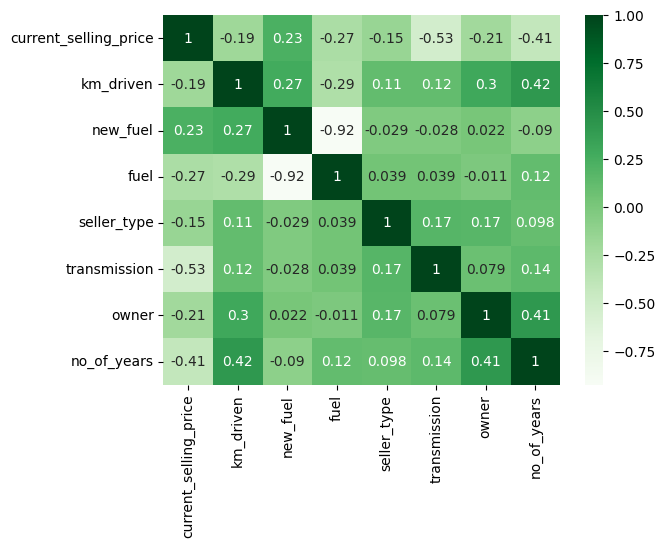

In [42]:
# heatmap 
sns.heatmap(df.corr(),annot = True,cmap='Greens')

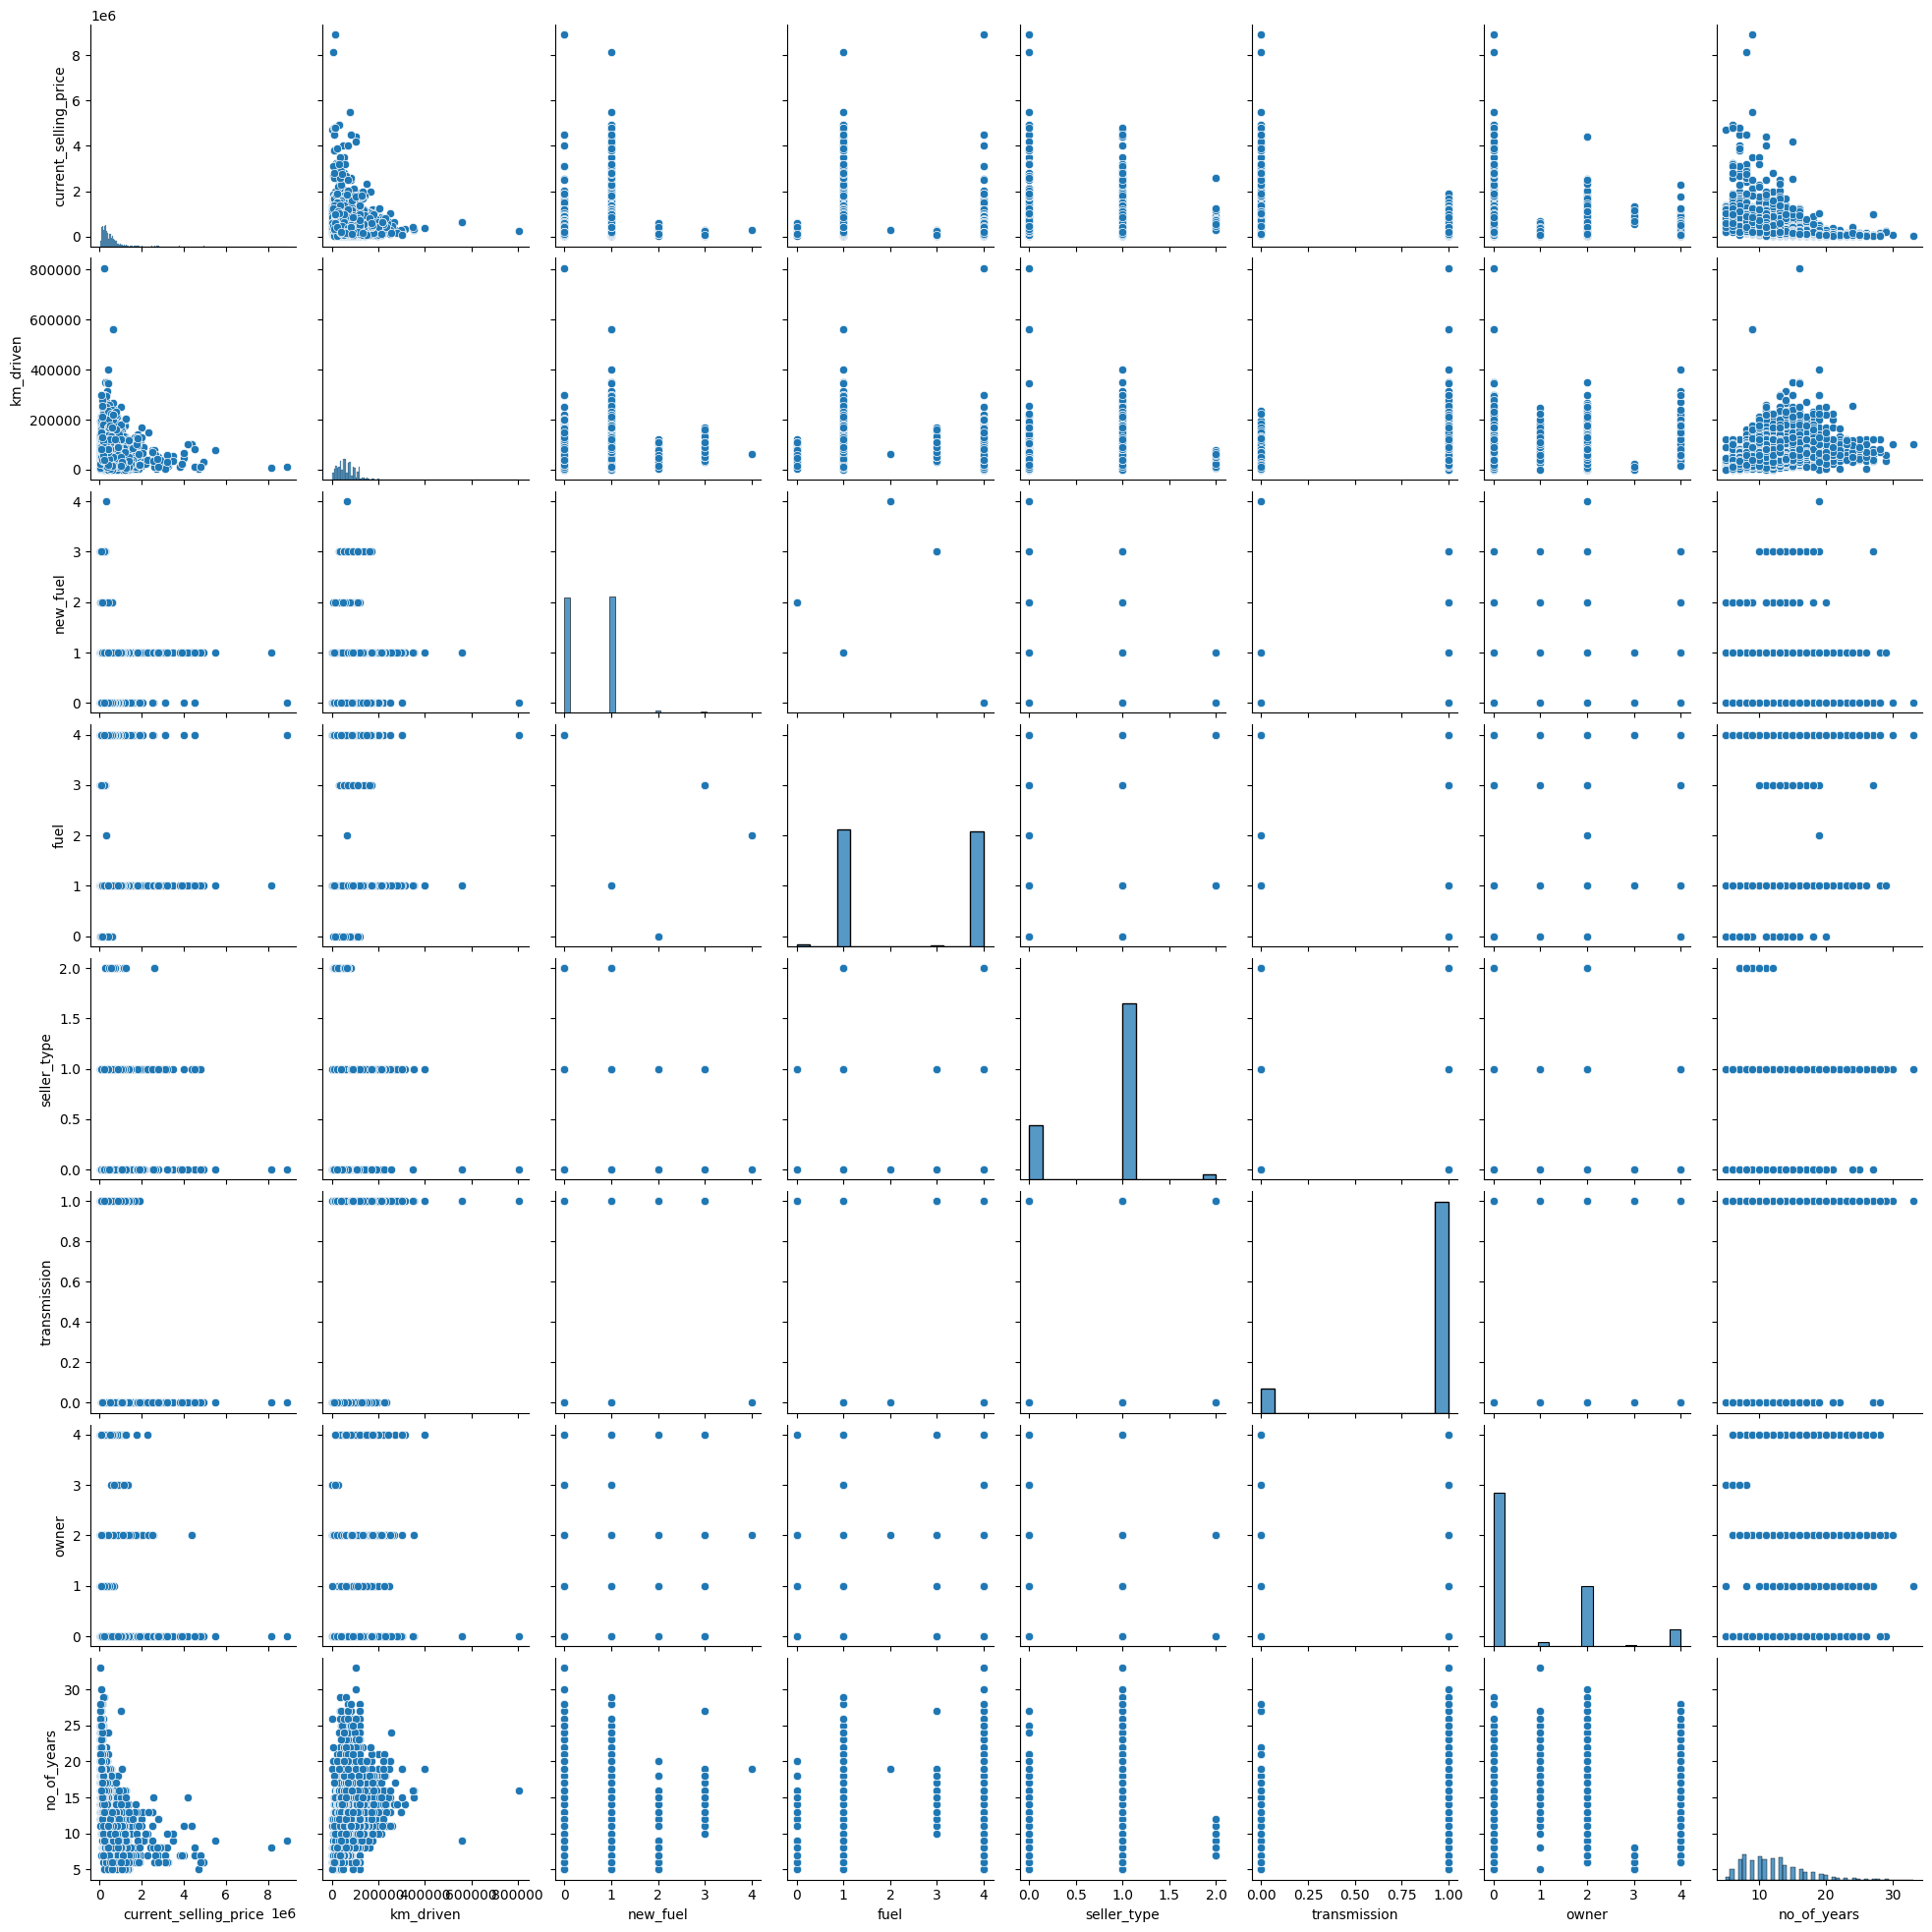

In [43]:
# Pairplot 
sns.pairplot(df)

<Axes: >

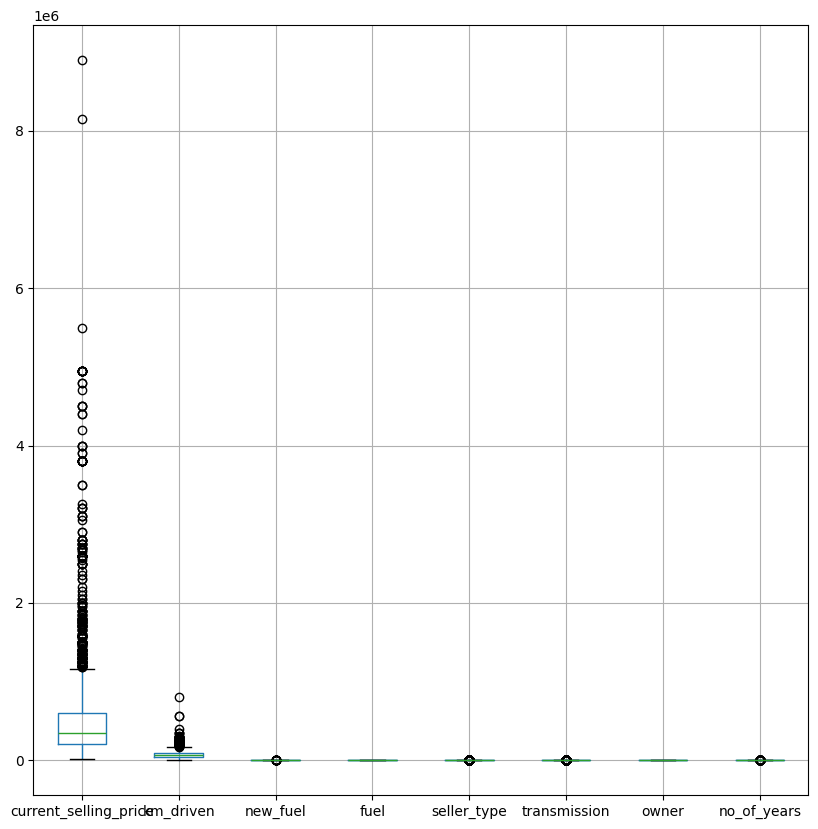

In [44]:
plt.figure(figsize=(10,10))
df.boxplot()

# Machine Leaning 

## Select the features and targets 

In [84]:
X= np.array(df.drop(columns=['current_selling_price'],axis = 1))
Y = np.array(df.current_selling_price).ravel()

# Spliting the data 

In [85]:
x_train, x_test , y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=22)

In [47]:
len(x_train)

3472

In [48]:
len(y_train)

3472

# Choosing the Model 

In [86]:
dt = DecisionTreeRegressor(random_state=42)

# Training the model`

In [88]:
# Step 2: Define parameter grid
param_dist = {
    'max_depth': [None, 3, 5, 8, 12, 15, 20],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error']
}

# Step 3: RandomizedSearchCV
dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=50,             # number of random combinations to try
    scoring='r2',          # optimize for R2
    cv=5,                  # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   current_selling_price  4340 non-null   int64
 1   km_driven              4340 non-null   int64
 2   new_fuel               4340 non-null   int64
 3   fuel                   4340 non-null   int32
 4   seller_type            4340 non-null   int32
 5   transmission           4340 non-null   int32
 6   owner                  4340 non-null   int32
 7   no_of_years            4340 non-null   int64
dtypes: int32(4), int64(4)
memory usage: 203.6 KB


In [90]:
dt_random.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'friedman_mse',
                                                      'absolute_error'],
                                        'max_depth': [None, 3, 5, 8, 12, 15,
                                                      20],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 8, 10],
                                        'min_samples_split': [2, 5, 10, 15,
                                                              20]},
                   random_state=42, scoring='r2', verbose=2)

# Testing the Model

In [91]:
# Step 5️⃣: Show best parameters and CV R²
print("Best Parameters:", dt_random.best_params_)
print("Best CV R2 Score:", dt_random.best_score_)

# Step 6️⃣: Use best model for prediction
best_dt = dt_random.best_estimator_
y_pred = best_dt.predict(x_test)

# Step 7️⃣: Evaluate performance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Test R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Parameters: {'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 12, 'criterion': 'squared_error'}
Best CV R2 Score: 0.5487537382995591
Test R2: 0.6919058794190138
MAE: 185430.50243554148
RMSE: 348910.6127689103


In [52]:
y_pred=regressor.predict(x_test)

In [53]:
target = pd.DataFrame({'Actual':y_test,'predicted':y_pred})

In [54]:
target.head()

,Actual,predicted
0,725000,514000.000000
1,150000,300000.000000
2,780000,623750.000000
3,217000,349999.666667
4,425000,725000.000000


In [55]:
print(x_test.shape)
print(y_test.shape)
print(y_pred.shape)

(868, 7)
(868,)
(868,)


Text(0.5, 1.0, 'Actual vs Predicted')

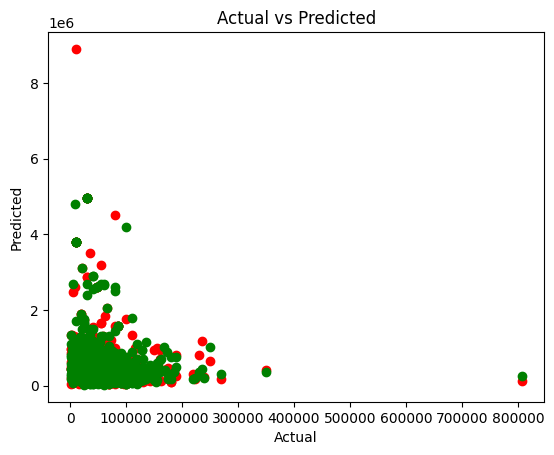

In [56]:
x_single = x_test[:, 0].reshape(-1, 1) 
plt.scatter(x_single,y_pred.reshape(-1,1),color = 'red')
plt.scatter(x_single,y_test.reshape(-1,1),color = 'green')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
# plt.plot()

<Axes: >

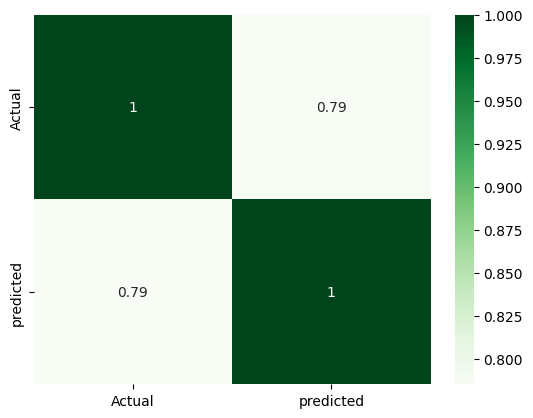

In [57]:
sns.heatmap(target.corr(),annot=True , cmap ='Greens')

# Performance 

In [58]:
r2_score (y_test , y_pred)

0.5437243328810005

In [59]:
# use Feature selection and scalling to raise the performance score 

# Extra 

In [60]:
new_df = df.copy()

In [61]:
new_df.columns

Index(['current_selling_price', 'km_driven', 'new_fuel', 'fuel', 'seller_type',
       'transmission', 'owner', 'no_of_years'],
      dtype='object')

In [62]:
new_df = new_df[['fuel','seller_type']]

In [63]:
new_df.head()

,fuel,seller_type
0,4,1
1,4,1
2,1,1
3,4,1
4,1,1


In [64]:
type(new_df) 

pandas.core.frame.DataFrame

In [65]:
from sklearn.preprocessing import LabelEncoder

In [66]:
new_df['fuel'] = LabelEncoder().fit_transform(new_df['fuel'])

In [67]:
new_df['fuel'].unique()

array([4, 1, 0, 3, 2], dtype=int64)

In [68]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [69]:
new_df = pd.get_dummies(new_df) #inbuilt pandas function for One-Hot Encoder 

In [70]:
encoder =OneHotEncoder()

In [71]:
new_df['fuel'] = encoder.fit_transform(new_df[['fuel']]).toarray()

In [72]:
new_df['fuel']

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
4335    0.0
4336    0.0
4337    0.0
4338    0.0
4339    0.0
Name: fuel, Length: 4340, dtype: float64

In [73]:
encoded_fuel_df = pd.DataFrame(new_df['fuel'], columns=encoder.get_feature_names_out(['fuel']))

In [74]:
# Concatenate with the original DataFrame
new_df = pd.concat([new_df, encoded_fuel_df], axis=1)

# (Optional) Drop the original 'fuel' column
new_df.drop('fuel', axis=1, inplace=True)

In [75]:
new_df

,seller_type,fuel_0,fuel_1,fuel_2,fuel_3,fuel_4
0,1,NaN,NaN,NaN,NaN,NaN
1,1,NaN,NaN,NaN,NaN,NaN
2,1,NaN,NaN,NaN,NaN,NaN
3,1,NaN,NaN,NaN,NaN,NaN
4,1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
4335,1,NaN,NaN,NaN,NaN,NaN
4336,1,NaN,NaN,NaN,NaN,NaN
4337,1,NaN,NaN,NaN,NaN,NaN
4338,1,NaN,NaN,NaN,NaN,NaN


In [76]:
new_df['fuel']

KeyError: 'fuel'